In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [160]:
from google.colab import files
import pandas as pd
import io

# 1. Trigger the file upload selector
uploaded = files.upload()

# 2. Get the filename dynamically
filename = list(uploaded.keys())[0]

# 3. Read the uploaded CSV file with the correct encoding
df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin1')
print(df.head())


Saving Credit Card.csv to Credit Card.csv
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.2

In [162]:
file=pd.read_csv("Credit Card.csv")

In [163]:
file.head(10)



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [164]:
file.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [165]:
file.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [166]:
file['Class'].value_counts()

,count
Class,
0,284315
1,492


In [167]:
normal=file[file.Class==0]

In [120]:
data_file.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [168]:
fraud=file[file.Class==1]

In [169]:
print(normal.shape)

(284315, 31)


In [170]:
print(normal.shape)

(284315, 31)


In [171]:
normal.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [172]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [173]:
file.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [174]:
normal_sample=normal.sample(n=492)

In [175]:
new_file=pd.concat([normal_sample,fraud],axis=0)

In [176]:
new_file.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
243199,151839.0,2.073131,-0.942133,-0.449587,-0.452007,-0.976757,-0.212599,-0.935702,-0.020490,0.004046,...,-0.572405,-1.158874,0.497774,0.619028,-0.718247,0.242634,-0.018012,-0.026551,37.53,0
49002,43870.0,0.933643,-1.813246,0.412537,-1.178043,-1.683822,-0.316799,-0.708096,-0.179528,-1.966664,...,-0.161645,-0.636868,-0.046059,0.076996,0.001376,-0.413980,0.016262,0.076651,285.70,0
168128,119077.0,-0.510456,-0.579299,1.086602,-0.030873,0.191775,-0.233133,-0.212415,0.205563,0.745866,...,0.231962,0.420719,0.412815,-0.679401,-1.377459,0.107816,0.213178,0.278085,95.80,0
117317,74632.0,-1.084240,0.732290,1.922229,1.488520,-0.431214,1.293041,-0.454684,1.022769,0.205327,...,-0.282691,-0.459654,-0.043724,-0.300060,-0.011512,-0.366690,0.312575,0.086100,24.98,0
111726,72342.0,1.115087,-0.020947,-0.251505,1.119197,0.526665,0.667019,0.191596,0.011791,0.263730,...,-0.138533,-0.293236,-0.311995,-1.282937,0.847286,-0.236720,0.028408,0.016874,85.44,0
146510,87737.0,2.074533,0.128127,-1.648395,0.446810,-0.078968,-2.309725,0.756638,-0.630626,0.009321,...,0.174477,0.589752,0.113157,0.992479,0.161260,0.743146,-0.132686,-0.078377,1.90,0
228572,145571.0,1.617662,-1.306175,-0.226383,-0.498446,-1.340899,-0.594110,-0.606869,-0.104550,1.713086,...,0.170946,0.287724,0.128451,0.068232,-0.644407,0.513637,-0.042828,-0.005190,208.60,0
141504,84363.0,1.257264,0.319818,0.294030,0.696664,-0.413130,-1.082234,0.052203,-0.175073,0.108343,...,-0.293986,-0.871440,0.135106,0.326151,0.200140,0.096469,-0.026243,0.029612,1.29,0
164068,116425.0,1.790400,-0.279312,-1.748121,1.464996,0.186921,-1.067659,0.650316,-0.388939,0.355505,...,0.361724,0.953171,-0.244179,-0.062280,0.535727,-0.268414,-0.041499,-0.044443,135.00,0
251031,155179.0,-1.146755,0.574223,0.915759,-1.885238,-0.170184,-0.536482,0.272510,0.405262,-1.479431,...,-0.779480,-2.070394,0.113894,0.544039,0.240888,-0.426261,0.130912,0.044231,41.44,0


In [177]:
new_file['Class'].value_counts()

,count
Class,
0,492
1,492


In [178]:
new_file.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,96929.459350,0.089141,-0.157728,-0.085137,0.064068,0.058007,0.018019,0.063358,0.018839,-0.014935,...,-0.020381,0.004790,0.012498,-0.044976,0.027401,-0.013722,0.007597,-0.016288,0.021195,95.798476
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


In [179]:
X=new_file.drop(columns='Class',axis=1)
Y=new_file['Class']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)
model=LogisticRegression()

In [180]:
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [181]:
X_train_prediction=model.predict(X_train)

In [182]:
training_data_acuracy=accuracy_score(X_train_prediction,Y_train)*100

In [183]:
print(f"Training Data Accuracy: {training_data_acuracy}%")

Training Data Accuracy: 94.91740787801778%


In [184]:
X_test_prediction=model.predict(X_test)

In [185]:
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)*100

In [186]:
print(f"Test Data Accuracy: {test_data_accuracy}%")

Test Data Accuracy: 93.90862944162437%


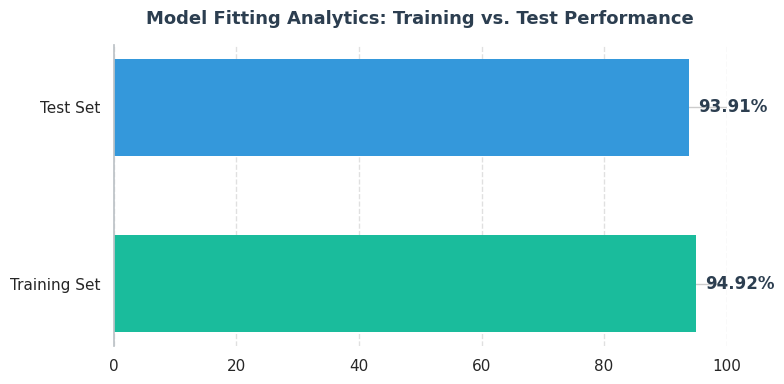

In [187]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define data points based on your accuracy metrics
datasets = ['Training Set', 'Test Set']
accuracies = [training_data_acuracy, test_data_accuracy]
colors = ['#1abc9c', '#3498db']  # Cyan/Teal for Training, Blue for Test

# 2. Initialize figure canvas layout
fig, ax = plt.subplots(figsize=(8, 4))

# 3. Create horizontal analytics bars
bars = ax.barh(datasets, accuracies, color=colors, height=0.55, edgecolor='none')

# 4. Annotate each metric with a precise, clean decimal label
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2,
            f'{width:.2f}%',
            va='center', ha='left',
            fontweight='bold', fontsize=12, color='#2c3e50')

# 5. Fine-tune visual layout bounds and remove messy border lines
ax.set_xlim(0, 100)
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#cccccc') # Soft background grid lines
ax.set_axisbelow(True) # Push grid lines behind the data bars

# Clean up top, right, and bottom box borders
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#bdc3c7') # Keep clean left axis anchor line

plt.title('Model Fitting Analytics: Training vs. Test Performance', fontsize=13, fontweight='bold', pad=15, color='#2c3e50')
plt.tight_layout()
plt.show()
